In [6]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;
from scipy.signal import welch;

# Styling.
plt.style.use("bmh");

In [ ]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_PERTURB_-0.3";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = True);
dt_diag = reader.fetch_dt_diag(directory_path);
jacobian_dictionary = reader.fetch_jacobian(directory_path);
aspect_ratio = reader.fetch_aspect_ratio(directory_path);
safety_factor = reader.fetch_safety_factor_flat(directory_path);
restart_times = gys_utils.calculate_restart_times(directory_path);

Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    3.8s finished


Finished compiling data from all files in the directory.
Found line: "NB_RESTART   = 5".
Isolating value...
Success: Got value 5.
Found line: "nbiter        = 400".
Isolating value...
Success: Got value 400.


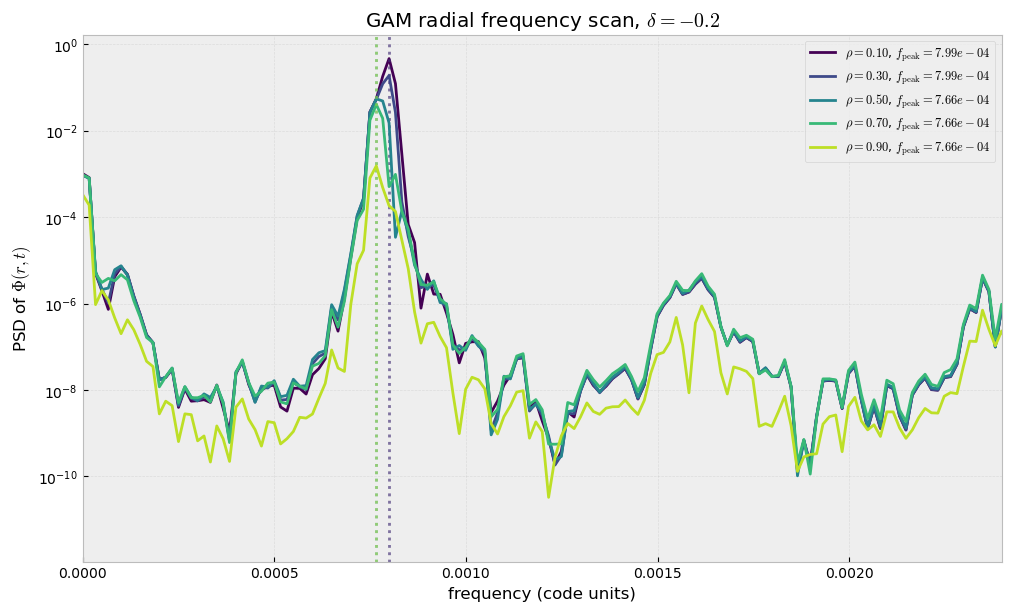

In [ ]:
# TODO: ai generated!
def plot_radial_frequency_scan(phi2D_list, jacobian_dictionary, dt_diag, radii = (0.1, 0.3, 0.5, 0.7, 0.9), figsize = (10, 6), title_suffix = ""):
	
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary);
	phi = np.asarray(radial_time_series.values);
	radial_dim = [d for d in radial_time_series.dims if d != "time"][0];
	radial_axis = np.asarray(radial_time_series.coords[radial_dim].values);

	fs = 1.0 / dt_diag;
	nperseg = min(phi.shape[0], 2048);

	fig, ax = plt.subplots(figsize = figsize, constrained_layout = True);
	colors = plt.cm.viridis(np.linspace(0, 0.9, len(radii)));

	peak_frequencies = [];
	for rho_target, color in zip(radii, colors):

		i = int(round(rho_target * len(radial_axis)));
		rho_actual = radial_axis[i];
		freqs, psd = welch(phi[:, i], fs = fs, nperseg = nperseg);
		f_peak = freqs[np.argmax(psd[1:]) + 1];
		peak_frequencies.append((rho_actual, f_peak));
		ax.semilogy(freqs, psd, color = color,
					label = f"$\\rho = {rho_target:.2f}$, $f_{{\\rm peak}} = {f_peak:.2e}$");
		ax.axvline(f_peak, color = color, linestyle = ":", alpha = 0.4);

	ax.set_xlabel("frequency (code units)");
	ax.set_ylabel("PSD of $\\Phi(r, t)$");
	ax.set_title(f"GAM radial frequency scan, {title_suffix}");
	ax.legend(fontsize = 9);
	ax.grid(True, alpha = 0.3);

	f_peaks = np.array([fp for _, fp in peak_frequencies]);
	df = f_peaks.max() - f_peaks.min();
	f_max_for_xlim = f_peaks.max() * 3;
	ax.set_xlim(0, f_max_for_xlim);

	return fig, peak_frequencies, df;

plot_radial_frequency_scan(data_arrays, jacobian_dictionary, dt_diag, title_suffix = r"$\delta = -0.3$");